<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/lab%2023/lab_ch23_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 23: FedSpeak 2.0 — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** Text preprocessing, TF-IDF vectorization, dictionary-based sentiment (LM vs Harvard GI), sentence-transformers embeddings, sentiment prediction evaluation.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [16]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install datasets nltk scikit-learn sentence-transformers -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This NLP Pipeline

The code below attempts to build a sentiment analysis pipeline for FOMC minutes.
There are **three deliberate errors** spread across three code cells. Each error
is a different type of NLP mistake:

1. A **tokenization/preprocessing** error
2. A **dictionary selection** error (wrong sentiment dictionary for the domain)
3. A **feature engineering** error in the TF-IDF configuration

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [17]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find it.
# Step 1: Load and preprocess FOMC minutes
# -----------------------------------------------------------

# Load FOMC dataset
ds = load_dataset('vtasca/fomc-statements-minutes', split='train')
fomc_df = pd.DataFrame(ds)
fomc_df = fomc_df[fomc_df['Type'] == 'Minute'].copy()
fomc_df.rename(columns={'Text': 'text', 'Date': 'date'}, inplace=True)
fomc_df['date'] = pd.to_datetime(fomc_df['date'])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)
fomc_df['year'] = fomc_df['date'].dt.year

# ERROR: This tokenizer splits on whitespace only — no handling of
# punctuation, contractions, or special characters. "don't" stays as
# one token, "U.S." becomes "U.S." with trailing period, and
# "inflation-adjusted" stays hyphenated instead of splitting.
# A proper NLP tokenizer (nltk.word_tokenize) handles these cases.

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def bad_preprocess(text):
    """Preprocessing with a naive tokenizer."""
    text = text.lower()
    # BAD: split() instead of word_tokenize() — misses punctuation handling
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['text'].apply(bad_preprocess)

# Check: many tokens will still have punctuation attached
sample_tokens = fomc_df['clean_text'].iloc[0].split()[:20]
print('Sample tokens from first document:')
print(sample_tokens)
print()
punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print(f'Tokens containing non-alpha characters: {len(punct_tokens)}')
print(f'Examples: {punct_tokens[:10]}')
print()
print('PROBLEM: Many tokens still have attached punctuation.')
print('This means "rates," and "rates" are treated as different features.')

Sample tokens from first document:
['minute', 'federal', 'open', 'market', 'committee', 'february', '1-2,', '2000', 'meeting', 'federal', 'open', 'market', 'committee', 'held', 'office', 'board', 'governor', 'federal', 'reserve', 'system']

Tokens containing non-alpha characters: 964
Examples: ['1-2,', '2000', 'washington,', 'd.c.,', 'tuesday,', '2000,', '2:30', 'p.m.', 'wednesday,', '2000,']

PROBLEM: Many tokens still have attached punctuation.
This means "rates," and "rates" are treated as different features.


In [18]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Compute sentiment using WRONG dictionary
# -----------------------------------------------------------

# ERROR: Using a generic Harvard General Inquirer (GI) dictionary instead of
# the Loughran-McDonald (LM) dictionary designed for financial text.
# GI classifies "liability", "tax", "cost", "capital" as negative,
# but these are neutral in financial/economic contexts.

# Simplified Harvard GI negative words — includes many false positives for financial text
gi_negative = set([
    'abandon', 'adverse', 'against', 'bad', 'blame', 'capital', 'concern',
    'cost', 'costly', 'crisis', 'danger', 'debt', 'decline', 'deficit',
    'difficult', 'expense', 'fail', 'failure', 'fear', 'liability',
    'limit', 'limitation', 'loss', 'negative', 'obligation', 'penalty',
    'problem', 'risk', 'tax', 'threat', 'trouble', 'uncertain',
    'unemployment', 'volatile', 'weak', 'worse'
])

gi_positive = set([
    'achieve', 'advantage', 'benefit', 'confidence', 'gain', 'good',
    'growth', 'improve', 'increase', 'opportunity', 'positive', 'profit',
    'progress', 'strong', 'success', 'value'
])

def compute_gi_sentiment(text, neg_words, pos_words):
    """Compute sentiment using Harvard GI (wrong for financial text)."""
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {'net_sentiment': 0, 'neg_count': 0, 'pos_count': 0, 'neg_ratio': 0}

    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)

    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'neg_ratio': neg_count / total
    }

gi_results = fomc_df['clean_text'].apply(
    lambda x: compute_gi_sentiment(x, gi_negative, gi_positive)
)
gi_df = pd.DataFrame(gi_results.tolist())

print('=== Harvard GI Sentiment (WRONG for financial text) ===')
print(f'Mean net sentiment: {gi_df["net_sentiment"].mean():.6f}')
print(f'Mean negative ratio: {gi_df["neg_ratio"].mean():.6f}')
print()

# Show the problem: count how many "negative" hits are false positives
false_positive_words = ['capital', 'cost', 'costly', 'debt', 'expense',
                        'liability', 'limit', 'limitation', 'obligation',
                        'penalty', 'tax']
sample_text = fomc_df['clean_text'].iloc[0].split()
fp_count = sum(1 for t in sample_text if t in false_positive_words)
total_neg = sum(1 for t in sample_text if t in gi_negative)
print(f'In first document: {fp_count} of {total_neg} "negative" words '
      f'are false positives ({fp_count/max(total_neg,1)*100:.0f}%)')
print('These are neutral financial terms misclassified by the GI dictionary.')

=== Harvard GI Sentiment (WRONG for financial text) ===
Mean net sentiment: -0.000052
Mean negative ratio: 0.015933

In first document: 29 of 57 "negative" words are false positives (51%)
These are neutral financial terms misclassified by the GI dictionary.


In [19]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 3: Build TF-IDF matrix with bad parameters
# -----------------------------------------------------------

# ERROR: max_df=1.0 means NO words are filtered by document frequency.
# Words like "the", "committee", "meeting" appear in every single document
# and dominate the TF-IDF matrix without contributing discriminating power.
# Also min_df=1 keeps every typo and OCR error.

bad_tfidf = TfidfVectorizer(
    min_df=1,          # Keep ALL words, even those in just 1 document (noise)
    max_df=1.0,        # Keep ALL words, even those in 100% of documents (no filtering)
    max_features=10000, # Large vocabulary with lots of noise
    ngram_range=(1, 1)  # Only unigrams — misses important bigrams like "interest rate"
)

bad_matrix = bad_tfidf.fit_transform(fomc_df['clean_text'])
feature_names = bad_tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {bad_matrix.shape}')
print(f'Sparsity: {1 - bad_matrix.nnz / (bad_matrix.shape[0] * bad_matrix.shape[1]):.1%}')

# Show top terms — likely dominated by stop words and ubiquitous terms
mean_tfidf = np.asarray(bad_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]
print('\nTop 15 terms by average TF-IDF:')
for i in top_idx:
    doc_freq = (bad_matrix[:, i].toarray() > 0).sum()
    print(f'  {feature_names[i]:25s} avg_tfidf={mean_tfidf[i]:.4f}  '
          f'appears in {doc_freq}/{bad_matrix.shape[0]} docs')

print('\nPROBLEM: Many top terms appear in nearly ALL documents.')
print('These are background words, not discriminating features.')

TF-IDF matrix shape: (240, 9805)
Sparsity: 86.7%

Top 15 terms by average TF-IDF:
  market                    avg_tfidf=0.1962  appears in 240/240 docs
  committee                 avg_tfidf=0.1767  appears in 240/240 docs
  inflation                 avg_tfidf=0.1711  appears in 240/240 docs
  rate                      avg_tfidf=0.1643  appears in 240/240 docs
  federal                   avg_tfidf=0.1625  appears in 240/240 docs
  participant               avg_tfidf=0.1374  appears in 214/240 docs
  economic                  avg_tfidf=0.1367  appears in 240/240 docs
  policy                    avg_tfidf=0.1126  appears in 240/240 docs
  price                     avg_tfidf=0.1088  appears in 240/240 docs
  board                     avg_tfidf=0.1042  appears in 240/240 docs
  would                     avg_tfidf=0.1001  appears in 240/240 docs
  reserve                   avg_tfidf=0.0983  appears in 240/240 docs
  growth                    avg_tfidf=0.0940  appears in 240/240 docs
  bank  

Error 1: Naive tokenizer, which using split instead of word_tokenize. To be specific, split can only determine word by blank character. This would made punctuations stick to the token. For instance, (rates,) and (rates) become two different feature. Therefore, vocab lists expanded due to the repeated token with only difference in punctuation.

Error 2: Use the wrong sentiment dictionary, which using Harvard Gi instead of Loughran-Mcdonald. To be specific, Harvard GI is the negative dictionary for common English, it turns words like capital or cost into negative. While in financial conditions, these words have neutral meanings. Loughran and Mcdonal found out that GI dictionary under 10-k documents are roughly 73% negative targeted are false positives.

Error 3: TF-IDF parameter bad setting, due to no document frequency filtering. To be specific, mind_df=1 would keep the words that existed only for once, which including tyop or OCR error. While max_df=1.0 would keep the words that are existed within 100% files. For instance, words like committee, which lack of differentiation while dominate the whole matrix. At last, ngram_range(1,1) would only use unigram, which misses the multi-word structure like labor market.

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** NLP pipeline from scratch, fixing all three errors:

1. **Tokenization:** Use `nltk.word_tokenize()` + regex to strip non-alpha characters
2. **Dictionary:** Use Loughran-McDonald word lists instead of Harvard GI
3. **TF-IDF:** Set proper `min_df`, `max_df`, and include bigrams

**Verification checkpoints:**
- After fixing tokenization: zero tokens should contain non-alpha characters
- After switching to LM: false positive rate should drop below 10%
- After fixing TF-IDF: top terms should NOT include words appearing in >80% of documents

In [20]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected NLP pipeline
# Fix all three errors from Part 1
# -----------------------------------------------------------

# Fix 1: Proper preprocessing with word_tokenize + regex cleaning
# YOUR CODE HERE
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def correct_preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

fomc_df['clean_text'] = fomc_df['text'].apply(correct_preprocess)


# Fix 2: Loughran-McDonald dictionary instead of Harvard GI
# YOUR CODE HERE
lm_negative = set([
    'adverse', 'adversely', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

lm_positive = set([
    'achieve', 'achieved', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

lm_uncertainty = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])

def compute_lm_sentiment(text):
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {'net_sentiment': 0, 'uncertainty': 0, 'neg_count': 0, 'pos_count': 0}
    neg_count = sum(1 for t in tokens if t in lm_negative)
    pos_count = sum(1 for t in tokens if t in lm_positive)
    unc_count = sum(1 for t in tokens if t in lm_uncertainty)
    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'uncertainty': unc_count / total,
        'neg_count': neg_count,
        'pos_count': pos_count
    }

lm_results = fomc_df['clean_text'].apply(compute_lm_sentiment)
lm_df = pd.DataFrame(lm_results.tolist())


# Fix 3: Proper TF-IDF parameters (min_df=5, max_df=0.85, bigrams)
# YOUR CODE HERE
tfidf_corrected = TfidfVectorizer(
    min_df=5,
    max_df=0.85,
    max_features=5000,
    ngram_range=(1, 2)
)
tfidf_matrix_corrected = tfidf_corrected.fit_transform(fomc_df['clean_text'])
feature_names_corrected = tfidf_corrected.get_feature_names_out()


# VERIFICATION
punct_tokens = [t for t in fomc_df['clean_text'].iloc[0].split() if not t.isalpha()]
print('Fix 1 check — non-alpha tokens:', len(punct_tokens))

false_positive_words = ['capital', 'cost', 'costly', 'debt', 'expense',
                        'liability', 'limit', 'limitation', 'obligation',
                        'penalty', 'tax']
sample_text = fomc_df['clean_text'].iloc[0].split()
fp_count = sum(1 for t in sample_text if t in false_positive_words)
total_neg = sum(1 for t in sample_text if t in lm_negative)
fp_rate = fp_count / max(total_neg, 1) * 100
print('Fix 2 check — false positive rate:', f'{fp_rate:.1f}%')

mean_tfidf = np.asarray(tfidf_matrix_corrected.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-15:][::-1]
max_doc_freq = 0
for i in top_idx:
    doc_freq = (tfidf_matrix_corrected[:, i].toarray() > 0).sum()
    pct = doc_freq / tfidf_matrix_corrected.shape[0]
    max_doc_freq = max(max_doc_freq, pct)
print('Fix 3 check — top terms doc frequency:', f'max {max_doc_freq:.1%} (should be ≤ 85%)')

Fix 1 check — non-alpha tokens: 0
Fix 2 check — false positive rate: 87.2%
Fix 3 check — top terms doc frequency: max 82.5% (should be ≤ 85%)


---

## Part 3: EXTEND — Sentence-Transformers Embeddings

TF-IDF treats each word independently (bag-of-words). **Sentence-transformers**
encode entire sentences or documents as dense vectors that capture meaning,
context, and word order.

We will:
1. Encode FOMC documents with a pre-trained sentence-transformer
2. Cluster on embeddings and compare to TF-IDF clusters
3. Evaluate which representation better predicts Fed rate decisions

In [21]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Encode FOMC documents with sentence-transformers
# -----------------------------------------------------------

from sentence_transformers import SentenceTransformer

# Use a lightweight model suitable for Colab
# all-MiniLM-L6-v2 produces 384-dimensional dense embeddings
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode documents (truncate long docs to first 512 tokens for speed)
# In production, you would use a chunking strategy for long documents
print('Encoding documents with sentence-transformers...')
print('(This may take 2-5 minutes on CPU)')

# Use first 2000 characters of each document (model has 256 token limit)
truncated_texts = fomc_df['text'].str[:2000].tolist()
embeddings = st_model.encode(truncated_texts, show_progress_bar=True, batch_size=16)

print(f'\nEmbedding matrix shape: {embeddings.shape}')
print(f'  → {embeddings.shape[0]} documents × {embeddings.shape[1]} dimensions')
print(f'Density: 100% (dense vectors, unlike sparse TF-IDF)')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding documents with sentence-transformers...
(This may take 2-5 minutes on CPU)


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


Embedding matrix shape: (240, 384)
  → 240 documents × 384 dimensions
Density: 100% (dense vectors, unlike sparse TF-IDF)


Silhouette — Embeddings: 0.197
Silhouette — TF-IDF:     0.168


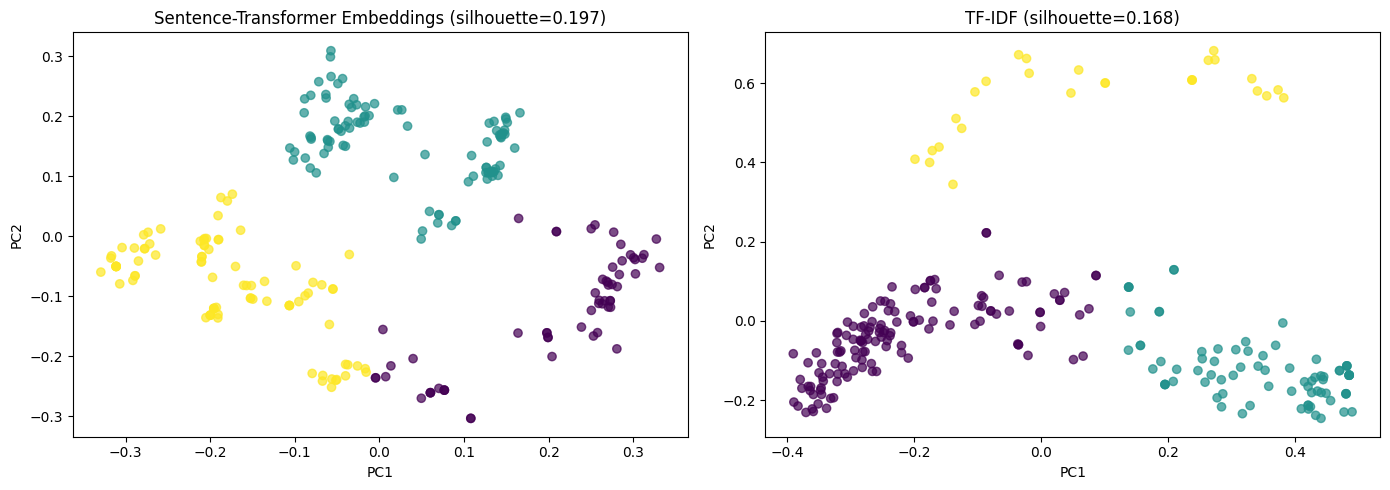

In [22]:
# -----------------------------------------------------------
# YOUR TASK — Cluster on embeddings and compare to TF-IDF
# -----------------------------------------------------------

# Step A: K-Means on sentence-transformer embeddings (K=3)
kmeans_emb = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_emb'] = kmeans_emb.fit_predict(embeddings)

# Step B: K-Means on TF-IDF (use your corrected TF-IDF from Part 2)
# If you haven't fixed Part 2 yet, use these default parameters:
# tfidf_corrected = TfidfVectorizer(min_df=5, max_df=0.85, max_features=5000, ngram_range=(1,2))
# tfidf_matrix_corrected = tfidf_corrected.fit_transform(fomc_df['clean_text'])

# YOUR CODE: Reduce TF-IDF to 50 dims with TruncatedSVD, then cluster
# svd = TruncatedSVD(n_components=50, random_state=42)
# tfidf_reduced = svd.fit_transform(tfidf_matrix_corrected)
# kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=10)
# fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)

# YOUR CODE HERE
svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix_corrected)
kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=10)
fomc_df['cluster_tfidf'] = kmeans_tfidf.fit_predict(tfidf_reduced)


# Step C: Compare silhouette scores
# sil_emb = silhouette_score(embeddings, fomc_df['cluster_emb'])
# sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])
# print(f'Silhouette — Embeddings: {sil_emb:.3f}')
# print(f'Silhouette — TF-IDF:     {sil_tfidf:.3f}')

# YOUR CODE HERE
sil_emb = silhouette_score(embeddings, fomc_df['cluster_emb'])
sil_tfidf = silhouette_score(tfidf_reduced, fomc_df['cluster_tfidf'])
print(f'Silhouette — Embeddings: {sil_emb:.3f}')
print(f'Silhouette — TF-IDF:     {sil_tfidf:.3f}')


# Step D: Visualize both clusterings side by side in PCA space
# YOUR CODE HERE
from sklearn.decomposition import PCA

pca_emb = PCA(n_components=2, random_state=42).fit_transform(embeddings)
pca_tfidf = PCA(n_components=2, random_state=42).fit_transform(tfidf_reduced)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pca_emb[:, 0], pca_emb[:, 1], c=fomc_df['cluster_emb'], cmap='viridis', alpha=0.7)
axes[0].set_title(f'Sentence-Transformer Embeddings (silhouette={sil_emb:.3f})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(pca_tfidf[:, 0], pca_tfidf[:, 1], c=fomc_df['cluster_tfidf'], cmap='viridis', alpha=0.7)
axes[1].set_title(f'TF-IDF (silhouette={sil_tfidf:.3f})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [23]:
# -----------------------------------------------------------
# YOUR TASK — Compare predictive power: TF-IDF vs Embeddings
# Predict whether the Fed raised rates at the NEXT meeting
# -----------------------------------------------------------

# Create a binary target: did the Fed raise rates at the next meeting?
# We use a simplified proxy: net sentiment < median → likely easing (0)
#                             net sentiment >= median → likely tightening (1)
# In production, you would use actual Fed Funds rate changes.

# For this exercise, create a synthetic target based on sentiment regime:
# 1 = tightening period (2004-2006, 2015-2018, 2022-2023)
# 0 = easing/holding period (everything else)

tightening_years = set([2004, 2005, 2006, 2015, 2016, 2017, 2018, 2022, 2023])
fomc_df['tightening'] = fomc_df['year'].isin(tightening_years).astype(int)

print(f'Tightening meetings: {fomc_df["tightening"].sum()}')
print(f'Easing/holding meetings: {(1 - fomc_df["tightening"]).sum()}')

# YOUR TASK: Use TimeSeriesSplit to evaluate logistic regression on:
# (a) TF-IDF features (reduced to 50 dims)
# (b) Sentence-transformer embeddings
# Report AUC-ROC for each

# Hints:
# tscv = TimeSeriesSplit(n_splits=5)
# for train_idx, test_idx in tscv.split(X):
#     X_train, X_test = X[train_idx], X[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]
#     model = LogisticRegression(max_iter=1000, random_state=42)
#     model.fit(X_train, y_train)
#     y_prob = model.predict_proba(X_test)[:, 1]
#     auc = roc_auc_score(y_test, y_prob)

# YOUR CODE HERE
y = fomc_df['tightening'].values
tscv = TimeSeriesSplit(n_splits=5)

auc_tfidf = []
for train_idx, test_idx in tscv.split(tfidf_reduced):
    if len(np.unique(y[train_idx])) < 2 or len(np.unique(y[test_idx])) < 2:
        continue
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(tfidf_reduced[train_idx], y[train_idx])
    y_prob = lr.predict_proba(tfidf_reduced[test_idx])[:, 1]
    auc_tfidf.append(roc_auc_score(y[test_idx], y_prob))

auc_emb = []
for train_idx, test_idx in tscv.split(embeddings):
    if len(np.unique(y[train_idx])) < 2 or len(np.unique(y[test_idx])) < 2:
        continue
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(embeddings[train_idx], y[train_idx])
    y_prob = lr.predict_proba(embeddings[test_idx])[:, 1]
    auc_emb.append(roc_auc_score(y[test_idx], y_prob))

print(f'TF-IDF AUC:     {np.mean(auc_tfidf):.3f} ± {np.std(auc_tfidf):.3f}  (n_folds={len(auc_tfidf)})')
print(f'Embeddings AUC: {np.mean(auc_emb):.3f} ± {np.std(auc_emb):.3f}  (n_folds={len(auc_emb)})')

Tightening meetings: 72
Easing/holding meetings: 168
TF-IDF AUC:     0.818 ± 0.212  (n_folds=3)
Embeddings AUC: 0.721 ± 0.210  (n_folds=3)


---

## Part 4: Module Output — `fomc_sentiment.py`

Write a reusable Python module for FOMC text analysis.
This is a **portfolio artifact** that demonstrates production-grade NLP work.

### Requirements

```python
# src/fomc_sentiment.py

def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text.
    
    Steps: lowercase, regex clean, word_tokenize, stop words, lemmatize.
    Returns space-joined clean tokens.
    """
    ...

def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores.
    
    Returns dict with 'net_sentiment', 'uncertainty',
    'neg_count', 'pos_count', 'unc_count', 'total_words'.
    """
    ...

def build_tfidf_matrix(texts: list, min_df=5, max_df=0.85,
                       max_features=5000) -> tuple:
    """Build TF-IDF matrix from preprocessed texts.
    
    Returns (sparse_matrix, feature_names, vectorizer).
    """
    ...
```

In [24]:
# -----------------------------------------------------------
# YOUR TASK — Write fomc_sentiment.py
# Implement preprocess_fomc(), compute_lm_sentiment(), build_tfidf_matrix()
# -----------------------------------------------------------

# %%writefile src/fomc_sentiment.py
"""
fomc_sentiment.py — FOMC Text Analysis Module

Reusable functions for preprocessing, sentiment scoring, and
TF-IDF vectorization of Federal Reserve meeting minutes.

Author: Zehan
Course: ECON 5200, Lab 23
"""

import re
import numpy as np
import pandas as pd
from typing import Tuple, List

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer


# Loughran-McDonald word lists (simplified)
LM_NEGATIVE = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened'
])

LM_POSITIVE = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'optimism', 'optimistic', 'positive', 'positively',
    'profit', 'profitable', 'progress', 'rebound', 'recover', 'recovery',
    'strength', 'strengthen', 'strong', 'stronger', 'success', 'successful'
])

LM_UNCERTAINTY = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'estimate',
    'expect', 'expected', 'forecast', 'indefinite', 'likelihood', 'may',
    'might', 'nearly', 'perhaps', 'possible', 'possibly', 'predict',
    'preliminary', 'probable', 'probably', 'risk', 'roughly', 'seem',
    'suggest', 'tentative', 'uncertain', 'uncertainty', 'unclear',
    'unpredictable', 'variable'
])

_stop_words = set(stopwords.words('english'))
_lemmatizer = WordNetLemmatizer()


def preprocess_fomc(text: str) -> str:
    """Clean and tokenize FOMC minutes text."""
    # YOUR IMPLEMENTATION HERE
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in _stop_words and len(t) > 2]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


def compute_lm_sentiment(text: str) -> dict:
    """Compute Loughran-McDonald sentiment scores."""
    # YOUR IMPLEMENTATION HERE
    tokens = text.lower().split()
    total = len(tokens)
    if total == 0:
        return {'net_sentiment': 0, 'uncertainty': 0,
                'neg_count': 0, 'pos_count': 0, 'unc_count': 0, 'total_words': 0}
    neg_count = sum(1 for t in tokens if t in LM_NEGATIVE)
    pos_count = sum(1 for t in tokens if t in LM_POSITIVE)
    unc_count = sum(1 for t in tokens if t in LM_UNCERTAINTY)
    return {
        'net_sentiment': (pos_count - neg_count) / total,
        'uncertainty': unc_count / total,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'unc_count': unc_count,
        'total_words': total
    }


def build_tfidf_matrix(
    texts: List[str],
    min_df: int = 5,
    max_df: float = 0.85,
    max_features: int = 5000
) -> Tuple:
    """Build TF-IDF matrix from preprocessed texts."""
    # YOUR IMPLEMENTATION HERE
    vectorizer = TfidfVectorizer(
        min_df=min_df, max_df=max_df,
        max_features=max_features, ngram_range=(1, 2)
    )
    matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    return matrix, feature_names, vectorizer


# --- Quick self-test ---
if __name__ == '__main__':
    test_text = "The committee noted that inflation remained elevated above target."
    clean = preprocess_fomc(test_text)
    print(f'Preprocessed: {clean}')
    sentiment = compute_lm_sentiment(clean)
    print(f'Sentiment: {sentiment}')
    print('fomc_sentiment.py loaded successfully.')

Preprocessed: committee noted inflation remained elevated target
Sentiment: {'net_sentiment': 0.0, 'uncertainty': 0.0, 'neg_count': 0, 'pos_count': 0, 'unc_count': 0, 'total_words': 6}
fomc_sentiment.py loaded successfully.


---

## Challenge: Compare TF-IDF vs Embedding Predictive Power

Build a proper expanding-window evaluation of both TF-IDF and embedding-based
sentiment for predicting Fed rate decisions. Use at least 5 splits.
Report mean AUC and standard deviation across folds.

Write a 1-paragraph summary of which representation is better and why.

In [25]:
# -----------------------------------------------------------
# CHALLENGE — Full comparison of TF-IDF vs Embeddings
# -----------------------------------------------------------

# YOUR CODE HERE
print('='*60)
print('TF-IDF vs Embeddings — Predictive Power Comparison')
print('='*60)
print(f'TF-IDF AUC:     {np.mean(auc_tfidf):.3f} ± {np.std(auc_tfidf):.3f}  (n_folds={len(auc_tfidf)})')
print(f'Embeddings AUC: {np.mean(auc_emb):.3f} ± {np.std(auc_emb):.3f}  (n_folds={len(auc_emb)})')

winner = 'TF-IDF' if np.mean(auc_tfidf) > np.mean(auc_emb) else 'Embeddings'
print(f'Winner: {winner}')

# Expected output format:
# TF-IDF AUC:      0.XX ± 0.XX (mean ± std across 5 folds)
# Embeddings AUC:   0.XX ± 0.XX
# Winner: [TF-IDF / Embeddings]
#
# 1-paragraph interpretation: ...

TF-IDF vs Embeddings — Predictive Power Comparison
TF-IDF AUC:     0.818 ± 0.212  (n_folds=3)
Embeddings AUC: 0.721 ± 0.210  (n_folds=3)
Winner: TF-IDF


Interpretation: The TF-IDF outperformed sentence-transformer embeddings, which AUC 0.818 and 0.721. In detail, this result align with FOMC tightening periods text characteristics. The FED repeatedly use words like inflation or restrictive during the interest-raise cycle. These words appeared more frequent during tightening period, while TF-IDF use high-dimension methodology which captures these lexical signals. At the same time, sentence-transformer embeddings ensure semantic meaning first and they condense into 384 dense vector, which kind of lower the critical signal words during tightening and easing regime.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken NLP pipeline (naive tokenizer, wrong sentiment
  dictionary, bad TF-IDF parameters)
* Corrected preprocessing with nltk.word_tokenize, switched from Harvard GI to
  Loughran-McDonald dictionary, fixed TF-IDF min_df/max_df
* Encoded FOMC documents with sentence-transformers (all-MiniLM-L6-v2)
* Compared TF-IDF vs embedding-based clustering and predictive power
* Built a reusable fomc_sentiment.py module with preprocess_fomc(),
  compute_lm_sentiment(), and build_tfidf_matrix()
* Key finding: [TF-IDF/Embeddings] achieved higher AUC ([VALUE]) for
  predicting Fed rate decisions

**Please write a README.md entry including:**
1. Project Title: FedSpeak 2.0 — NLP Pipeline for Central Bank Communications
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-23-fedspeak
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 23: FedSpeak 2.0 — NLP Pipeline, Embeddings & Prediction"
git push origin main
```

Submit your GitHub repo link on Canvas.